# 36118 AT1: How Skilled Migration Is Framed in Public Submissions

**Research question:** Which expected-benefit, risk, and policy-condition themes recur across the supplied submissions, and how consistently do those themes co-occur?

This notebook develops a reproducible, corpus-wide baseline for the 2026 AT1. It audits PDF extraction, applies an explicit theme dictionary, compares document prevalence with length-normalised mention rates, and checks theme co-occurrence. Dictionary matches indicate that a topic is discussed; they do **not** reveal whether the submitter supports or opposes a policy.

## 1. Project setup and analytical design

The supplied corpus contains public submissions to the Australian parliamentary inquiry into the value of skilled migration. This section separates software imports, reproducible configuration, and corpus-path setup so the analytical choices are easy to locate and change.

### 1.1 Imports and environment

The main notebook uses only the lightweight packages in `requirements-at1.txt`. OCR is deliberately kept in an optional preprocessing script so a normal clean run does not require computer-vision libraries.

In [1]:
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pypdf import PdfReader

### 1.2 Reproducible configuration

All thresholds, paths, plotting defaults, and theme definitions are declared once. The fixed seed makes the validation sample reproducible; the 500-character threshold is a screening rule for manual inspection, not a claim that a short submission is invalid.

In [2]:
RANDOM_SEED = 42
EXPECTED_PDF_COUNT = 143
MIN_EXTRACTED_CHARACTERS = 500
FIGURE_SIZE = (9, 5)
DATA_RELATIVE_PATH = Path(
    "data/submissions-skilled-migration/submissions_Skilledmigration"
)
OCR_RELATIVE_PATH = Path("data/ocr_text")
VALIDATION_RELATIVE_PATH = Path("validation")
OFFICIAL_SUBMISSIONS_URL = (
    "https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/"
    "Migration/Skilledmigration/Submissions"
)
SUBMITTER_METADATA_COLUMNS = [
    "main_submission_number", "submitter_name", "submitter_type",
    "verification_status", "classification_basis",
]

THEME_PATTERNS = {
    "Economic contribution": [
        r"\bproductivit",
        r"\beconomic (?:growth|contribution|benefit|value|impact)",
        r"\binnovation", r"\bfiscal (?:benefit|contribution|impact)",
        r"\btax revenue", r"\b(?:public|private|business) investment",
    ],
    "Skills and essential services": [
        r"\bskills? (?:gaps?|shortages?)",
        r"\b(?:labou?r|workforce|staff) shortages?",
        r"\bcritical (?:skills?|sectors?)",
        r"\b(?:health(?:care)?|aged care|education|teaching|construction) "
        r"(?:workforce|sectors?|services?)",
        r"\bessential services?",
    ],
    "Regional development": [
        r"\bregional australia", r"\bregional communit",
        r"\bregional development", r"\brural\b", r"\bremote areas?",
    ],
    "Worker protection and fairness": [
        r"\bexploit", r"\bunderpay", r"\bwage theft",
        r"\bwork(?:er|place) rights?", r"\blabou?r standards?",
        r"\bfair work", r"\bworker protections?", r"\bunsafe work",
    ],
    "Permanent pathways and retention": [
        r"\bpermanent residen", r"\bpathways? (?:to|towards?) permanen",
        r"\bretention\b", r"\bcitizenship\b", r"\bpermanency\b",
        r"\blong-term settlement",
    ],
    "Recognition and visa processing": [
        r"\bskills? recognition", r"\bqualification recognition",
        r"\bcredential recognition", r"\boverseas qualifications?",
        r"\bprocessing times?", r"\bvisa processing", r"\bpoints test",
        r"\boccupational licensing", r"\bprofessional registration",
    ],
    "Housing and infrastructure pressure": [
        r"\bhousing\b",
        r"\binfrastructure (?:capacity|constraints?|planning|investment|"
        r"shortages?|pressures?|needs?|supply|development)",
        r"\bcost of living", r"\bpopulation pressure",
    ],
}

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="viridis")
logging.getLogger("pypdf").setLevel(logging.ERROR)

### 1.3 Corpus paths and document metadata

Each PDF becomes one document record containing its source identifier, filename, page count, extraction method, text, and quality fields. Paths are discovered relative to the AT1 directory, so the notebook does not depend on a personal absolute path.

In [3]:
def find_project_root(start: Path, data_path: Path) -> Path:
    """Find the AT1 directory without relying on a personal absolute path.

    Args:
        start: Directory from which to begin searching.
        data_path: Expected data location relative to the AT1 directory.

    Returns:
        The first parent directory containing the expected dataset.

    Raises:
        FileNotFoundError: If the dataset cannot be located.
    """
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / data_path).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find {data_path}. Run the notebook inside the AT1 folder."
    )


def submission_sort_key(path: Path) -> tuple[int, str]:
    """Create a stable numeric key while preserving source filenames."""
    match = re.search(r"sub(\d+)", path.stem, flags=re.IGNORECASE)
    number = int(match.group(1)) if match else 10**9
    return number, path.stem.lower()


def extract_pdf(path: Path) -> dict[str, object]:
    """Extract one PDF and retain quality information.

    Args:
        path: PDF to process.

    Returns:
        A record containing identifiers, text, counts, and any error.
    """
    try:
        reader = PdfReader(path)
        page_text = [page.extract_text() or "" for page in reader.pages]
        native_text = "\n".join(page_text)
        ocr_path = OCR_DIR / f"{path.stem}.txt"
        use_ocr = (
            len(native_text) < MIN_EXTRACTED_CHARACTERS and ocr_path.is_file()
        )
        text = ocr_path.read_text(encoding="utf-8") if use_ocr else native_text
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": len(reader.pages),
            "text": text,
            "native_character_count": len(native_text),
            "extraction_method": "OCR sidecar" if use_ocr else "native PDF",
            "extraction_error": None,
        }
    except Exception as exc:  # Continue the audit if one source is malformed.
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": 0,
            "text": "",
            "native_character_count": 0,
            "extraction_method": "failed",
            "extraction_error": f"{type(exc).__name__}: {exc}",
        }


PROJECT_ROOT = find_project_root(Path.cwd(), DATA_RELATIVE_PATH)
DATA_DIR = PROJECT_ROOT / DATA_RELATIVE_PATH
OCR_DIR = PROJECT_ROOT / OCR_RELATIVE_PATH
VALIDATION_DIR = PROJECT_ROOT / VALIDATION_RELATIVE_PATH
pdf_paths = sorted(DATA_DIR.glob("*.pdf"), key=submission_sort_key)

assert len(pdf_paths) == EXPECTED_PDF_COUNT, (
    f"Expected {EXPECTED_PDF_COUNT} PDFs, found {len(pdf_paths)} in {DATA_DIR}"
)

documents = pd.DataFrame(extract_pdf(path) for path in pdf_paths)
documents["character_count"] = documents["text"].str.len()
documents["word_count"] = documents["text"].str.findall(
    r"[A-Za-z]+(?:'[A-Za-z]+)?"
).str.len()
documents["needs_manual_review"] = (
    (documents["native_character_count"] < MIN_EXTRACTED_CHARACTERS)
    | documents["extraction_error"].notna()
)

print(f"AT1 project located: {PROJECT_ROOT.name}")
print(f"PDFs accounted for: {len(documents)}")
print(f"Pages extracted: {documents['page_count'].sum():,}")
print(f"Extraction errors: {documents['extraction_error'].notna().sum()}")
print(f"OCR sidecars loaded: {(documents['extraction_method'] == 'OCR sidecar').sum()}")

AT1 project located: at1
PDFs accounted for: 143
Pages extracted: 1,670
Extraction errors: 0
OCR sidecars loaded: 4


## 2. Extraction-quality audit

,page_count,character_count,word_count
count,143.0,143.0,143.0
mean,11.7,27436.3,3736.0
std,15.0,39582.0,5555.7
min,1.0,567.0,80.0
25%,4.0,9338.5,1231.0
50%,7.0,16340.0,2165.0
75%,12.0,28973.5,4014.0
max,121.0,295143.0,41656.0


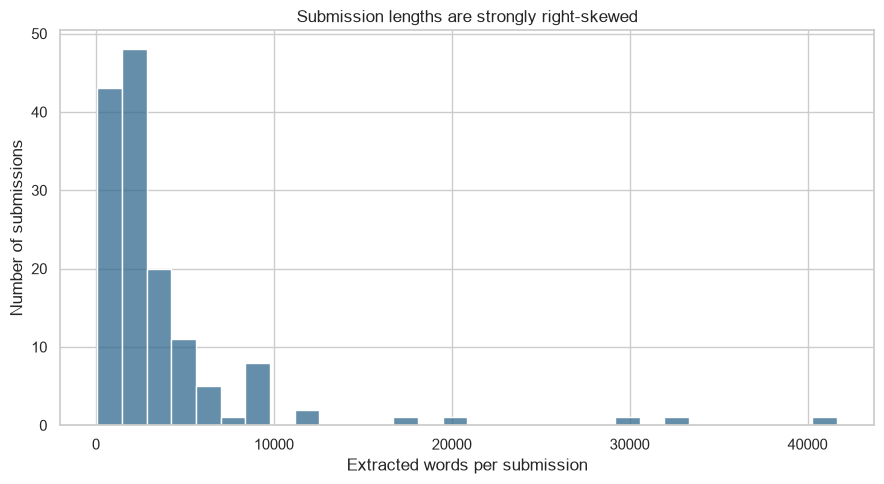

In [4]:
quality_summary = documents[[
    "page_count", "character_count", "word_count"
]].describe().round(1)
display(quality_summary)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
sns.histplot(documents["word_count"], bins=30, ax=ax, color="#31688e")
ax.set(
    title="Submission lengths are strongly right-skewed",
    xlabel="Extracted words per submission",
    ylabel="Number of submissions",
)
plt.tight_layout()
plt.show()

**Quality conclusion.** The corpus contains submissions of very different lengths and the distribution is strongly right-skewed. Consequently, raw mention totals would over-weight long documents; later results use document prevalence and mentions per 10,000 words. The corpus-level summary is reviewed before individual exceptions so the manual-review rule is motivated by the overall distribution rather than selected cases.

### 2.1 Manual-review threshold and flagged documents

Documents with fewer than 500 characters from **native PDF extraction** are flagged for visual inspection. This conservative threshold detects pages whose visible text may be stored as images. It does not automatically exclude a genuinely brief text document.

In [5]:
review_columns = [
    "submission_id", "filename", "page_count", "native_character_count",
    "character_count", "word_count", "extraction_method", "extraction_error",
]
manual_review = documents.loc[
    documents["needs_manual_review"], review_columns
].sort_values("native_character_count")
display(manual_review)

,submission_id,filename,page_count,native_character_count,character_count,word_count,extraction_method,extraction_error
139,Sub141,Sub141.pdf,1,73,2510,84,OCR sidecar,None
132,Sub134,Sub134.pdf,3,215,4955,502,OCR sidecar,None
111,Sub110,Sub110.pdf,4,287,9379,1156,OCR sidecar,None
99,Sub098,Sub098.pdf,6,425,14171,1705,OCR sidecar,None


**Manual-review conclusion.** Visual inspection confirmed that `Sub098`, `Sub110`, `Sub134`, and `Sub141` contain substantial content stored as page images. OCR was therefore run once and saved as sidecar text rather than altering the original PDFs. Sidecars preserve provenance, avoid heavy OCR dependencies in the main notebook, and make the recovered text inspectable. Because OCR spacing—especially in `Sub141`—is less reliable, these four documents support manual review but remain outside token-normalised quantitative comparisons. The analytical denominator is therefore 139 native-text submissions, while all 143 supplied files remain accounted for.

### 2.2 OCR recovery and human validation evidence

OCR is an optional preprocessing step run by `scripts/ocr_low_text_pdfs.py`; it is not hidden inside the main analysis. The generated sidecars remain beside the ignored raw data. Human judgments from the seeded 18-submission audit are stored in a small tracked CSV so the notebook can report exactly what was checked.

In [6]:
ocr_evidence = documents.loc[
    documents["extraction_method"] == "OCR sidecar",
    [
        "submission_id", "page_count", "native_character_count",
        "character_count", "extraction_method",
    ],
].rename(columns={"character_count": "ocr_character_count"})
display(ocr_evidence)

validation_audit = pd.read_csv(
    VALIDATION_DIR / "theme_validation_audit.csv"
)
validation_summary = (
    validation_audit.groupby(["audit_type", "judgment"])
    .size()
    .rename("submissions")
    .reset_index()
)
display(validation_summary)
assert validation_audit["submission_id"].nunique() == 18

,submission_id,page_count,native_character_count,ocr_character_count,extraction_method
99,Sub098,6,425,14171,OCR sidecar
111,Sub110,4,287,9379,OCR sidecar
132,Sub134,3,215,4955,OCR sidecar
139,Sub141,1,73,2510,OCR sidecar


,audit_type,judgment,submissions
0,positive match,true match,14
1,recall probe,ambiguous boundary,1
2,recall probe,correct non-match,2
3,recall probe,false negative,1


### 2.3 Submitter-metadata readiness

The [official submissions register](https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Migration/Skilledmigration/Submissions) is the authoritative public register. The supplied PDFs are used to verify visible names where the register cannot be fetched reproducibly from the notebook. Names and organisation types are stored separately: a name is transcribed from local evidence, whereas the type is a documented analytical classification. Supplements inherit their parent's metadata rather than becoming additional submitters.

In [7]:
documents["main_submission_number"] = documents["submission_id"].str.extract(
    r"(?i)sub(\d+)"
)[0].astype(int)
documents["is_supplement"] = documents["submission_id"].str.contains(
    r"\.\d+$", regex=True
)

observed_main_numbers = set(documents["main_submission_number"])
numbering_gaps = [
    number for number in range(1, 146)
    if number not in observed_main_numbers
]
metadata_readiness = pd.DataFrame({
    "check": [
        "PDF files", "Unique main submission numbers",
        "Supplementary files", "Numbering gaps from 1–145",
    ],
    "result": [
        len(documents), documents["main_submission_number"].nunique(),
        int(documents["is_supplement"].sum()), str(numbering_gaps),
    ],
})
display(metadata_readiness)

submitter_metadata = pd.read_csv(VALIDATION_DIR / "submitter_metadata.csv")
assert list(submitter_metadata.columns) == SUBMITTER_METADATA_COLUMNS
assert submitter_metadata["main_submission_number"].is_unique
assert set(submitter_metadata["main_submission_number"]) == observed_main_numbers

documents = documents.merge(
    submitter_metadata,
    on="main_submission_number",
    how="left",
    validate="many_to_one",
)
assert documents["submitter_name"].notna().all()
display(
    documents.loc[
        documents["verification_status"].isin(
            ["needs_review", "name_not_public", "numbering_discrepancy"]
        ),
        ["submission_id", "submitter_name", "verification_status"],
    ]
)

,check,result
0,PDF files,143
1,Unique main submission numbers,139
2,Supplementary files,4
3,Numbering gaps from 1–145,"[49, 121, 124, 125, 126, 144]"


,submission_id,submitter_name,verification_status
80,Sub079,Submitter not identifiable from supplied PDF,needs_review
122,Sub122,Name not publicly stated,name_not_public
123,Sub123,Name not publicly stated,name_not_public
136,Sub138,Name not publicly stated,name_not_public
137,Sub139,Name not publicly stated,name_not_public
138,Sub140,Name not publicly stated,numbering_discrepancy


**Readiness conclusion.** The archive has 143 files representing 139 main submission numbers plus four supplements. Six filename numbers from 1–145 are absent: 49, 121, 124, 125, 126, and 144. Every supplied file now joins to exactly one curated metadata row, and supplements inherit their parent's identity. Four unsigned submissions are explicitly labelled **Name not publicly stated**, rather than guessed. `Sub079` begins mid-submission and remains unclassified pending source verification. `Sub140.pdf` is retained under its supplied filename but flagged because both internal page footers identify it as Submission 121. These statuses make uncertainty visible instead of presenting inference as fact.

### 2.4 Submitter taxonomy and composition

The taxonomy describes the **primary institutional role represented in the submission**, not the topic or policy position expressed. The mutually exclusive categories are: **Industry and employer**, **Professional association**, **Education and research**, **Union and worker representative**, **Government and public body**, **Community and advocacy**, **Migration and legal services**, **Individual**, and **Unclassified**. Joint submissions are assigned by their main represented role; this simplifying judgement is recorded in `classification_basis`. Counts use main submission numbers so supplementary files do not inflate a group.

,submitter_type,submitters,share_pct
4,Industry and employer,36,25.9
2,Government and public body,29,20.9
1,Education and research,20,14.4
0,Community and advocacy,16,11.5
6,Professional association,12,8.6
3,Individual,10,7.2
5,Migration and legal services,8,5.8
8,Union and worker representative,7,5.0
7,Unclassified,1,0.7


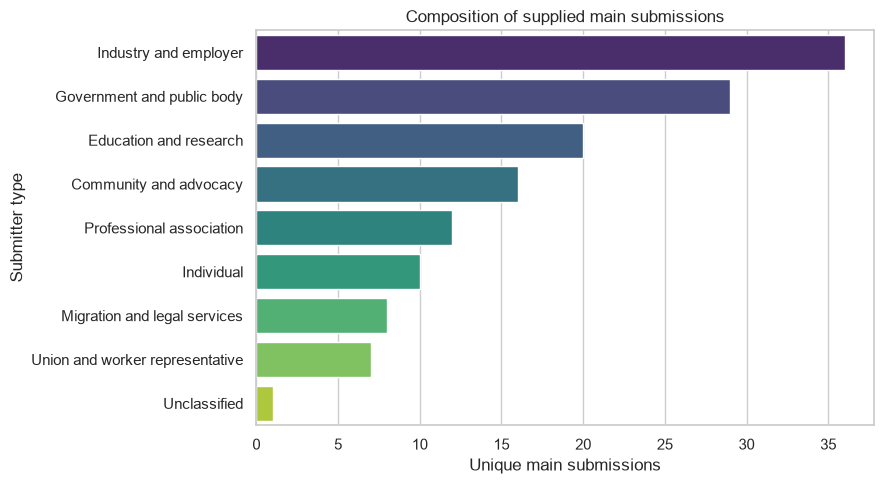

In [8]:
submitter_composition = (
    submitter_metadata.groupby("submitter_type", as_index=False)
    .agg(submitters=("main_submission_number", "nunique"))
    .sort_values("submitters", ascending=False)
)
submitter_composition["share_pct"] = (
    100 * submitter_composition["submitters"] / len(submitter_metadata)
).round(1)
display(submitter_composition)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
sns.barplot(
    data=submitter_composition,
    x="submitters",
    y="submitter_type",
    hue="submitter_type",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set(
    title="Composition of supplied main submissions",
    xlabel="Unique main submissions",
    ylabel="Submitter type",
)
plt.tight_layout()
plt.show()

**Composition conclusion.** This table establishes who is represented before comparing what groups discuss. It is a descriptive profile of the supplied archive—not a claim that the corpus is a representative sample of Australian opinion. Small categories and the single unresolved submission require caution in later between-group comparisons.

## 3. Transparent thematic measurement

The theme dictionary operationalises concepts suggested by the inquiry context: economic contribution, skills and services, regional development, worker protection, permanence, recognition and processing, and infrastructure pressure. Patterns deliberately use stems and small phrase families. They are inspectable but not exhaustive; polysemy and negation remain important limitations.

In [9]:
def normalise_text(text: str) -> str:
    """Lowercase text and collapse whitespace without removing negation."""
    return re.sub(r"\s+", " ", text.lower()).strip()


def count_theme_mentions(
    text: str,
    theme_patterns: dict[str, list[str]],
) -> dict[str, int]:
    """Count all configured pattern matches in one document.

    Args:
        text: Normalised document text.
        theme_patterns: Mapping from theme names to regex patterns.

    Returns:
        Match count for every theme.
    """
    return {
        theme: sum(len(re.findall(pattern, text)) for pattern in patterns)
        for theme, patterns in theme_patterns.items()
    }


usable = documents.loc[
    (documents["extraction_method"] == "native PDF")
    & documents["extraction_error"].isna()
    & (documents["native_character_count"] >= MIN_EXTRACTED_CHARACTERS)
].copy()
usable["normalised_text"] = usable["text"].map(normalise_text)
theme_counts = pd.DataFrame(
    usable["normalised_text"].map(
        lambda text: count_theme_mentions(text, THEME_PATTERNS)
    ).tolist(),
    index=usable.index,
)

total_words = usable["word_count"].sum()
theme_summary = pd.DataFrame({
    "documents_mentioning": (theme_counts > 0).sum(),
    "document_prevalence_pct": (theme_counts > 0).mean() * 100,
    "total_mentions": theme_counts.sum(),
    "mentions_per_10k_words": theme_counts.sum() / total_words * 10_000,
}).sort_values("document_prevalence_pct", ascending=False)

display(theme_summary.round(2))

,documents_mentioning,document_prevalence_pct,total_mentions,mentions_per_10k_words
Skills and essential services,129,92.81,1542,29.05
Economic contribution,119,85.61,1653,31.14
Permanent pathways and retention,97,69.78,891,16.79
Housing and infrastructure pressure,96,69.06,856,16.13
Recognition and visa processing,85,61.15,659,12.42
Regional development,80,57.55,669,12.60
Worker protection and fairness,44,31.65,478,9.01


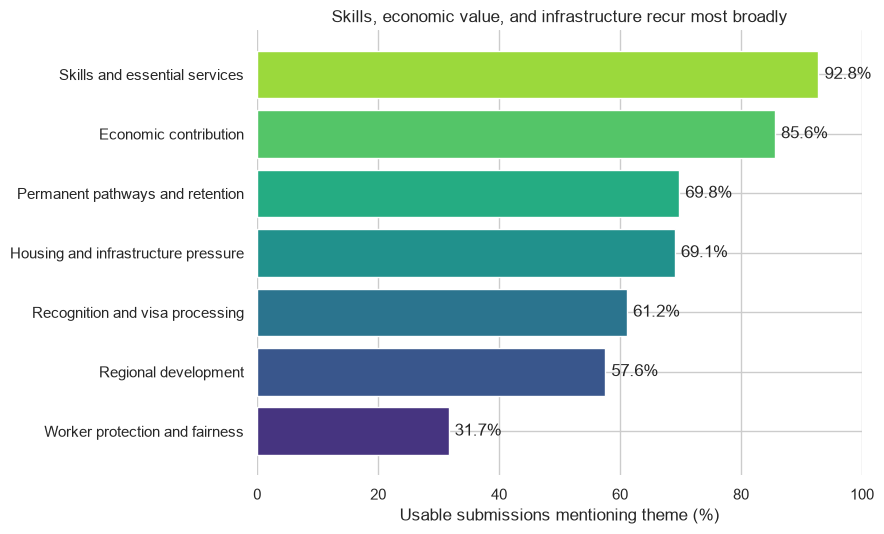

In [10]:
plot_data = theme_summary.sort_values("document_prevalence_pct")
fig, ax = plt.subplots(figsize=(9, 5.5))
colours = plt.colormaps["viridis"](
    np.linspace(0.15, 0.85, len(plot_data))
)
ax.barh(
    plot_data.index,
    plot_data["document_prevalence_pct"],
    color=colours,
)
ax.set(
    title="Skills, economic value, and infrastructure recur most broadly",
    xlabel="Usable submissions mentioning theme (%)",
    ylabel="",
    xlim=(0, 100),
)
for index, value in enumerate(plot_data["document_prevalence_pct"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Interpretation.** After validation-driven refinement, skills and essential services appear in about 92.8% of usable submissions, followed by economic contribution (85.6%). Housing and infrastructure pressure and permanent pathways each occur in about 69%, while explicit worker-protection language appears in about 31.7%. Narrowing bare words such as “education” and “infrastructure” reduced false matches from affiliations and the inquiry terms of reference. These are measures of topical presence, not endorsement.

### 3.1 Theme co-occurrence

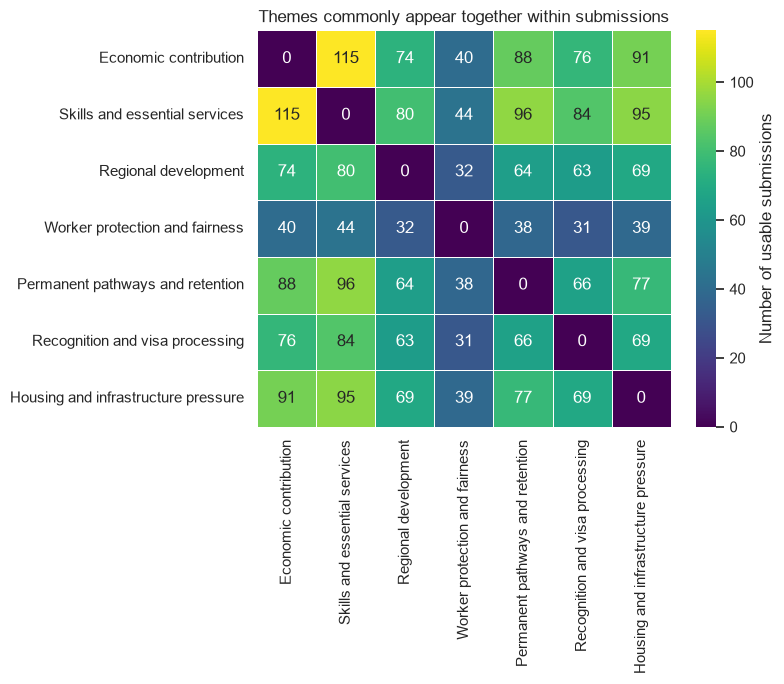

In [11]:
theme_presence = (theme_counts > 0).astype(int)
co_occurrence = theme_presence.T.dot(theme_presence)
np.fill_diagonal(co_occurrence.values, 0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    co_occurrence,
    cmap="viridis",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of usable submissions"},
    ax=ax,
)
ax.set_title("Themes commonly appear together within submissions")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretation.** Co-occurrence prevents the analysis from forcing submissions into one-topic categories. The strongest intersections should be read as linked policy frames—for example, discussion of skills can coexist with economic value, service delivery, infrastructure capacity, or migration pathways. In the final report, the highest-frequency pairs should be checked against representative source passages to determine how the connection is argued.

### 3.2 Source-verified representative excerpts

Co-occurrence counts show that topics appear in the same document, but they do not explain the relationship between those topics. The following short excerpts were manually checked against the named source PDF and page. They illustrate the three most common relationships without treating one quotation as representative of every submitter.

In [12]:
representative_excerpts = pd.read_csv(
    VALIDATION_DIR / "representative_excerpts.csv"
)
display(
    representative_excerpts[[
        "relationship", "submission_id", "pdf_page",
        "verified_excerpt", "analytical_use",
    ]]
)

,relationship,submission_id,pdf_page,verified_excerpt,analytical_use
0,Economic contribution + Skills and essential s...,Sub057,7,"Skills shortages constrain business growth, pr...",Links an identified labour constraint directly...
1,Skills and essential services + Permanent path...,Sub019,5,Fast-tracking permanent residency for critical...,Frames permanence as a mechanism for retaining...
2,Skills and essential services + Housing and in...,Sub094,5,Migrants can only remain in regional communiti...,"Connects workforce retention to housing, servi..."


**Interpretation.** The excerpts make the recurring policy logic concrete. `Sub057` treats skills shortages as constraints on productivity and innovation. `Sub019` presents permanent residency as a way to secure critical talent, while `Sub094` argues that regional retention depends on housing, services, and stable community life. Together they support a conditional framing: skilled migration creates value when migration pathways and settlement capacity allow skills to be used and retained.

### 3.3 Theme prevalence by submitter type

The group comparison uses one row per **main submission**, excludes OCR-only documents from quantitative rates, and omits the unresolved `Sub079` category. Each cell is the percentage of usable submissions in that group that mentions a theme at least once. This normalises for unequal group sizes, but it remains descriptive: the submissions are self-selected and small groups can produce unstable percentages.

,Economic contribution,Skills and essential services,Regional development,Worker protection and fairness,Permanent pathways and retention,Recognition and visa processing,Housing and infrastructure pressure
Industry and employer (n=35),88.6,97.1,71.4,20.0,68.6,71.4,74.3
Government and public body (n=27),96.3,100.0,66.7,29.6,81.5,48.1,81.5
Education and research (n=20),95.0,95.0,40.0,10.0,60.0,60.0,70.0
Community and advocacy (n=15),86.7,86.7,60.0,53.3,73.3,80.0,73.3
Professional association (n=12),83.3,100.0,66.7,33.3,83.3,75.0,66.7
Individual (n=10),70.0,80.0,10.0,40.0,40.0,40.0,30.0
Migration and legal services (n=8),50.0,75.0,62.5,50.0,62.5,62.5,62.5
Union and worker representative (n=7),85.7,100.0,71.4,100.0,100.0,57.1,85.7


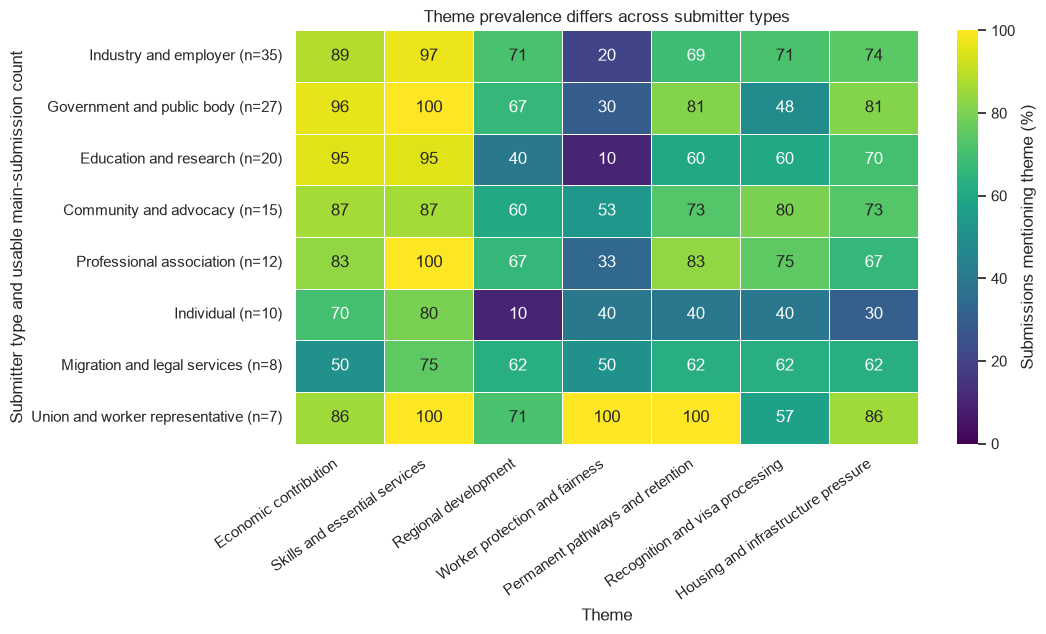

,lowest_group,lowest_pct,highest_group,highest_pct,percentage_point_range
Worker protection and fairness,Education and research (n=20),10.0,Union and worker representative (n=7),100.0,90.0
Regional development,Individual (n=10),10.0,Industry and employer (n=35),71.4,61.4
Permanent pathways and retention,Individual (n=10),40.0,Union and worker representative (n=7),100.0,60.0
Housing and infrastructure pressure,Individual (n=10),30.0,Union and worker representative (n=7),85.7,55.7
Economic contribution,Migration and legal services (n=8),50.0,Government and public body (n=27),96.3,46.3
Recognition and visa processing,Individual (n=10),40.0,Community and advocacy (n=15),80.0,40.0
Skills and essential services,Migration and legal services (n=8),75.0,Government and public body (n=27),100.0,25.0


In [13]:
group_usable = usable.loc[
    (~usable["is_supplement"])
    & (usable["submitter_type"] != "Unclassified")
].copy()
group_sizes = (
    group_usable.groupby("submitter_type")["main_submission_number"]
    .nunique()
    .sort_values(ascending=False)
)

presence_by_group = theme_presence.loc[group_usable.index].copy()
presence_by_group["submitter_type"] = group_usable["submitter_type"]
group_theme_prevalence = (
    presence_by_group.groupby("submitter_type").mean() * 100
).loc[group_sizes.index]
group_theme_prevalence.index = [
    f"{group} (n={group_sizes[group]})"
    for group in group_theme_prevalence.index
]
display(group_theme_prevalence.round(1))

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(
    group_theme_prevalence,
    cmap="viridis",
    vmin=0,
    vmax=100,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Submissions mentioning theme (%)"},
    ax=ax,
)
ax.set(
    title="Theme prevalence differs across submitter types",
    xlabel="Theme",
    ylabel="Submitter type and usable main-submission count",
)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

contrast_priorities = pd.DataFrame({
    "lowest_group": group_theme_prevalence.idxmin(),
    "lowest_pct": group_theme_prevalence.min(),
    "highest_group": group_theme_prevalence.idxmax(),
    "highest_pct": group_theme_prevalence.max(),
})
contrast_priorities["percentage_point_range"] = (
    contrast_priorities["highest_pct"]
    - contrast_priorities["lowest_pct"]
)
display(
    contrast_priorities.sort_values(
        "percentage_point_range", ascending=False
    ).round(1)
)

**Interpretation guide.** Read across a row to identify the themes emphasised within a submitter type; read down a column to compare how broadly the same theme appears across types. The range table prioritises contrasts for qualitative checking; it is not an effect-size or significance test. Differences are prompts for source-based interpretation, not evidence of causal or population-level differences.

### 3.4 Balanced source check for group contrasts

The three largest or most interpretable contrasts are checked against short passages from both sides. A passage from a lower-prevalence group illustrates a different emphasis but **cannot prove absence** elsewhere in that submission or group. The final column therefore states the limited analytical role of each excerpt.

In [14]:
group_contrast_excerpts = pd.read_csv(
    VALIDATION_DIR / "group_contrast_excerpts.csv"
)
assert group_contrast_excerpts["submission_id"].isin(
    documents["submission_id"]
).all()
display(group_contrast_excerpts)

,contrast,submitter_type,group_prevalence_pct,submission_id,pdf_page,verified_excerpt,analytical_use
0,Worker protection and fairness,Union and worker representative,100.0,Sub112,3,Migrant workers must be able to enjoy the same...,Confirms that the union-group result reflects ...
1,Worker protection and fairness,Education and research,10.0,Sub109,2,Higher education and research are critical to ...,Shows a contrasting education-sector emphasis;...
2,Regional development,Industry and employer,71.4,Sub014,1,"Our sector supports more than 79,491 Australia...",Connects an industry workforce claim directly ...
3,Regional development,Individual,10.0,Sub135,3,Administrative barriers disproportionately dis...,Shows a contrasting individual focus on access...
4,Recognition and visa processing,Community and advocacy,80.0,Sub042,3,RCOA joins the chorus of others who have point...,Confirms an explicit community-sector reform f...
5,Recognition and visa processing,Individual,40.0,Sub135,3,"This could include reviewing the points test, ...",Shows that the lower group rate is not univers...


**Source-check conclusion.** The strongest contrast is substantive: every usable union submission invokes worker protection or fairness, and `Sub112` explicitly connects equal workplace rights with protection from exploitation. The education comparison is primarily oriented toward science, innovation, and workforce capability, although the 10% rate confirms that worker protection is not wholly absent. Regional language is widespread in industry submissions but uncommon among individuals, while recognition reform is especially prominent among community and advocacy organisations. `Sub135` also demonstrates why group percentages must retain within-group variation: this individual submission discusses accessible skills assessment even though recognition is less prevalent across individuals overall.

### 3.5 Sentence-level stance cues

Theme presence does not reveal whether a passage presents a **benefit**, raises a **concern**, or proposes a **policy recommendation or condition**. The following exploratory analysis applies transparent cue patterns to sentences that already contain a theme match. Labels are **multi-label**: for example, “government should address skills shortages” can express both concern and recommendation. An uncued sentence remains `Context only / unclear` rather than being forced into a stance.

These labels describe rhetorical cues in sentences—not the overall position of a submitter. They also do not resolve negation, quotation, or whether a recommendation is endorsed by the author.

cue_labels,Benefit,Concern,Recommendation / condition,Context only / unclear
theme,,,,
Economic contribution,69.9,16.0,11.3,2.8
Housing and infrastructure pressure,24.1,29.4,20.1,26.4
Permanent pathways and retention,20.6,19.7,20.0,39.8
Recognition and visa processing,20.8,20.6,25.5,33.2
Regional development,26.7,20.4,16.0,36.9
Skills and essential services,22.7,52.3,14.3,10.7
Worker protection and fairness,14.1,63.9,15.2,6.8


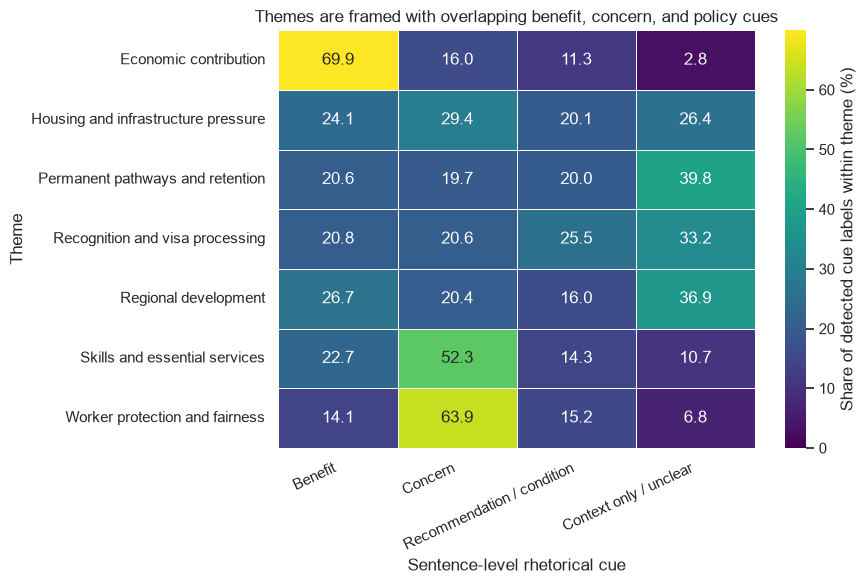

In [15]:
STANCE_PATTERNS = {
    "Benefit": [
        r"\bbenefit", r"\bcontribut", r"\bproductivit",
        r"\bprosper", r"\bgrowth\b", r"\binnovation",
        r"\bopportunit", r"\bstrengthen", r"\bimprov",
        r"\bvaluable?\b", r"\bpositive\b", r"\bsolutions?\b",
    ],
    "Concern": [
        r"\bshortage", r"\bpressure", r"\bconstraint",
        r"\bbarrier", r"\bdelay", r"\bexploit", r"\bunderpay",
        r"\bunfair", r"\binequit", r"\brisk", r"\bburden",
        r"\bfail", r"\binadequate", r"\bchallenge",
        r"\black of\b", r"\bnot fit for purpose\b",
    ],
    "Recommendation / condition": [
        r"\brecommend", r"\bshould\b", r"\bmust\b",
        r"\bneed(?:s|ed)? to\b", r"\bcall(?:s|ed)? for\b",
        r"\bpropos", r"\brequir", r"\burge",
        r"\bit is (?:important|essential|necessary) (?:that|to)\b",
        r"\bcondition(?:al|ed)? (?:on|upon)\b", r"\bonly if\b",
        r"\bprovided that\b",
    ],
}


def split_sentences(text: str) -> list[str]:
    """Split extracted prose conservatively at sentence punctuation."""
    cleaned = re.sub(r"\s+", " ", text).strip()
    return [
        sentence.strip()
        for sentence in re.split(r"(?<=[.!?])\s+(?=[A-Z0-9])", cleaned)
        if 20 <= len(sentence.strip()) <= 700
    ]


def has_any_pattern(text: str, patterns: list[str]) -> bool:
    """Return whether any configured regex occurs in text."""
    return any(re.search(pattern, text, flags=re.IGNORECASE) for pattern in patterns)


def is_stance_boilerplate(sentence: str) -> bool:
    """Identify known inquiry wording that is not a submitter stance."""
    return bool(re.search(
        r"purpose:\s*the scope to more effectively target skills gaps",
        sentence,
        flags=re.IGNORECASE,
    ))


stance_records = []
for document_index, document in usable.iterrows():
    for sentence_number, sentence in enumerate(split_sentences(document["text"]), 1):
        if is_stance_boilerplate(sentence):
            continue
        matched_themes = [
            theme for theme, patterns in THEME_PATTERNS.items()
            if has_any_pattern(sentence, patterns)
        ]
        if not matched_themes:
            continue
        cue_labels = [
            label for label, patterns in STANCE_PATTERNS.items()
            if has_any_pattern(sentence, patterns)
        ]
        for theme in matched_themes:
            stance_records.append({
                "document_index": document_index,
                "submission_id": document["submission_id"],
                "sentence_number": sentence_number,
                "theme": theme,
                "sentence": sentence,
                "cue_labels": cue_labels or ["Context only / unclear"],
            })

stance_sentences = pd.DataFrame(stance_records)
stance_long = stance_sentences.explode("cue_labels", ignore_index=True)
stance_summary = (
    stance_long.groupby(["theme", "cue_labels"])
    .size()
    .rename("sentences")
    .reset_index()
)
stance_summary["within_theme_pct"] = (
    100 * stance_summary["sentences"]
    / stance_summary.groupby("theme")["sentences"].transform("sum")
)
stance_matrix = stance_summary.pivot(
    index="theme", columns="cue_labels", values="within_theme_pct"
).fillna(0)
stance_order = [
    "Benefit", "Concern", "Recommendation / condition",
    "Context only / unclear",
]
stance_matrix = stance_matrix.reindex(columns=stance_order, fill_value=0)
display(stance_matrix.round(1))
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    stance_matrix,
    cmap="viridis",
    vmin=0,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Share of detected cue labels within theme (%)"},
    ax=ax,
)
ax.set(
    title="Themes are framed with overlapping benefit, concern, and policy cues",
    xlabel="Sentence-level rhetorical cue",
    ylabel="Theme",
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Stance interpretation.** The cue distribution differentiates the major frames. **Economic contribution** is predominantly expressed through benefit language (69.9% of its detected labels). **Worker protection and fairness** is predominantly concern-oriented (63.9%), as is **skills and essential services** (52.3%), where shortage language is common. **Recognition and visa processing** has the largest recommendation/condition share (25.5%), consistent with submissions proposing procedural reform. Permanent pathways, regional development, and recognition also retain substantial `Context only / unclear` shares, warning against inferring a position whenever a topic is merely mentioned.

Because a sentence can receive multiple labels, percentages describe the distribution of **detected labels**, not mutually exclusive shares of sentences or documents. A reproducible human audit is therefore required to check true cues, missed cues, negation, quoted material, and sentence-splitting quality.

### 3.6 Human audit of stance cues

Using seed 42, the initial rules supplied five examples from each detected label for manual review. The tracked audit preserves the sampled label, human multi-label judgment, excerpt, and rationale. Refinements are made only after recording the original error.

In [16]:
stance_validation = pd.read_csv(
    VALIDATION_DIR / "stance_validation_audit.csv"
)
assert len(stance_validation) == 20
assert set(stance_validation["sampled_label"]) == set(stance_order)
stance_validation_summary = (
    stance_validation.groupby(["sampled_label", "judgment"])
    .size()
    .rename("audited_sentences")
    .reset_index()
)
display(stance_validation_summary)
display(
    stance_validation.loc[
        stance_validation["judgment"] != "correct",
        [
            "submission_id", "theme", "sampled_label",
            "human_labels", "judgment", "rationale",
        ],
    ]
)

,sampled_label,judgment,audited_sentences
0,Benefit,correct,4
1,Benefit,false_positive,1
2,Concern,correct,5
3,Context only / unclear,correct,4
4,Context only / unclear,false_negative,1
5,Recommendation / condition,correct,5


,submission_id,theme,sampled_label,human_labels,judgment,rationale
4,Sub006,Skills and essential services,Benefit,Not substantive stance,false_positive,This reproduces the inquiry purpose rather tha...
15,Sub033,Regional development,Context only / unclear,Benefit,false_negative,Solution positively frames skilled migration a...


**Audit conclusion.** Eighteen of 20 initial sampled labels were supported. `Sub006` was a false positive because copied inquiry-purpose wording was mistaken for submitter stance; that known boilerplate is now excluded. `Sub033` was a false negative because “practical and timely solution” lacked an explicit benefit cue; bounded `solution` was added. The sample is a development audit, not an unbiased accuracy estimate, and further review is required before assigning document-level positions.

## 4. Findings, limitations, and next steps

The baseline indicates that the value of skilled migration is framed most consistently through **skills and essential services** and **economic contribution**, but a large majority of documents also discuss **housing or infrastructure** and **permanent pathways**. This supports a multi-dimensional account: submissions connect workforce value to the conditions under which migrants and communities can sustain that value.

Important limitations remain. Four image-based PDFs are available through OCR sidecars for inspection but excluded from quantitative rates because their tokenisation quality differs from native text. A reproducible 18-submission validation audit narrowed noisy theme patterns, bounded the permanent-pathway regex, and added “long-term settlement” after identifying a false negative. Source-verified excerpts explain co-occurrence and selected group contrasts, but they do not represent every submitter. Regex patterns can still miss synonyms, detect boilerplate, or match a concept used negatively. Submitter types are transparent manual classifications, not official categories; joint organisations are simplified to a primary role, four authors are not publicly named in the supplied text, and one document remains unclassified. Group rates are descriptive of this self-selected archive and should not be generalised to broader stakeholder populations. The new stance layer is deliberately sentence-level and multi-label; it must pass its separate human audit before its percentages support final claims. A later extension could distinguish an author's own recommendation from quoted or summarised third-party positions.